In [1]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import bilby
import lalsimulation as lalsim
import jax.numpy as jnp
from ripplegw.waveforms import IMRPhenomXPHM
import lal
from ripplegw.constants import C, MSUN
from tqdm import tqdm




/Users/harsh/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:

# %%

def compute_overlap(frequency_series_1, frequency_series_2):

    norm1 = np.sum(frequency_series_1*np.conj(frequency_series_1))**0.5
    norm2 = np.sum(frequency_series_2*np.conj(frequency_series_2))**0.5

    inner_product = np.sum(frequency_series_1*np.conj(frequency_series_2))
    return inner_product / (norm1*norm2)

N = 100## number of signals for which we want to compute overlap
collect_overlap = []
population = bilby.gw.prior.BBHPriorDict()
population['chirp_mass'] = bilby.core.prior.Uniform(10, 100)
population['mass_ratio'] = bilby.core.prior.Uniform(0.25, 1)
population.pop('mass_1')
population.pop('mass_2')

minimum_frequency = 20
duration = 8
reference_frequency = 50.
maximum_frequency = 1024



# %%


for ii in tqdm(range(N)):

    injection_parameters = bilby.gw.conversion.generate_all_bbh_parameters(population.sample(1))



    lalparams = lal.CreateDict()

    ModeArray = lalsim.SimInspiralCreateModeArray()

    lalsim.SimInspiralModeArrayActivateMode(ModeArray, 2, 1)
    lalsim.SimInspiralModeArrayActivateMode(ModeArray, 2, 2)

    lalsim.SimInspiralModeArrayActivateMode(ModeArray, 3, 2)
    lalsim.SimInspiralModeArrayActivateMode(ModeArray, 3, 3)

    lalsim.SimInspiralModeArrayActivateMode(ModeArray, 4, 4)




    lalsim.SimInspiralWaveformParamsInsertModeArray(lalparams, ModeArray)
    lalsim.SimInspiralWaveformParamsInsertPhenomXPHMTwistPhenomHM(lalparams, 1)
    lalsim.SimInspiralWaveformParamsInsertPhenomXPHMMBandVersion(lalparams, 0)
    lalsim.SimInspiralWaveformParamsInsertPhenomXPHMThresholdMband(lalparams, 0.0)
    lalsim.SimInspiralWaveformParamsInsertPhenomXPrecVersion(lalparams, 223)

    lal_hp_xphm, lal_hc_xphm = lalsim.SimIMRPhenomXPHM(float(injection_parameters['mass_1_source'][0]*MSUN),                       
                                               float(injection_parameters['mass_2_source'][0]*MSUN),                    
                                               injection_parameters['spin_1x'][0],                        #/**< x-component of the dimensionless spin_ of object 1 w.r.t. Lhat = (0,0,1) */
                                               injection_parameters['spin_1y'][0],                        #/**< y-component of the dimensionless spin_ of object 1 w.r.t. Lhat = (0,0,1) */
                                               injection_parameters['spin_1z'][0],                        #/**< z-component of the dimensionless spin_ of object 1 w.r.t. Lhat = (0,0,1) */
                                               injection_parameters['spin_2x'][0],                        #/**< x-component of the dimensionless spin_ of object 2 w.r.t. Lhat = (0,0,1) */
                                               injection_parameters['spin_2y'][0],                        #/**< y-component of the dimensionless spin_ of object 2 w.r.t. Lhat = (0,0,1) */
                                               injection_parameters['spin_2z'][0],                        #/**< z-component of the dimensionless spin_ of object 2 w.r.t. Lhat = (0,0,1) */
                                               injection_parameters['luminosity_distance'][0]*3.0856775814913673e22,                     #/**< Distance of source (m) */
                                               injection_parameters['iota'][0],                  #/**< inclination of source (rad) */
                                               0.0,                       #/**< Orbital phase (rad) at reference frequency */
                                               minimum_frequency,                        #/**< Starting GW frequency (Hz) */
                                               maximum_frequency,                        #/**< Ending GW frequency (Hz); Defaults to Mf = 0.3 if no f_max is specified. */
                                               1/duration,                       #/**< Sampling frequency (Hz). To use non-uniform frequency grid, set deltaF <= 0. */
                                               reference_frequency,                      #/**< Reference frequency (Hz) */
                                               lalparams                  #/**< LAL Dictionary struct */
                                               )
    

    ripple_hp_xphm, ripple_hc_xphm = IMRPhenomXPHM.generate_xphm(injection_parameters['mass_1_source'][0],
                                           injection_parameters['mass_2_source'][0],
                                            injection_parameters['spin_1x'][0],
                                            injection_parameters['spin_1y'][0],
                                            injection_parameters['spin_1z'][0],
                                            injection_parameters['spin_2x'][0],
                                            injection_parameters['spin_2y'][0],
                                            injection_parameters['spin_2z'][0],
                                            injection_parameters['luminosity_distance'][0] * 1e-3,
                                            injection_parameters['iota'][0],
                                            0.0,
                                            duration,
                                            minimum_frequency, maximum_frequency, reference_frequency,
                                            jnp.array([[2,1],[2,2],[3,2],[3,3],[4,4]]))
    

    fcut = int(duration*minimum_frequency)
    olp = compute_overlap(ripple_hp_xphm, np.array(lal_hp_xphm.data.data)[fcut:-1])



    #print(100*(1-olp))
    #print(compute_overlap(np.array(lal_hp_xphm.data.data)[fcut:-1], ripple_hp_xphm))
    collect_overlap.append(1.0-olp)




16:20 bilby INFO    : No prior given, using default BBH priors in /Users/harsh/Documents/phd-projects/packages/github-bilby/bilby/bilby/gw/prior_files/precessing_spins_bbh.prior.
  0%|          | 0/100 [00:00<?, ?it/s]/Users/harsh/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
  1%|          | 1/100 [00:07<11:47,  7.15s/it]/Users/harsh/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
  2%|▏         | 2/100 [00:08<06:30,  3.98s/it]/Users/harsh/opt/anaconda3/envs/myenv/lib/python

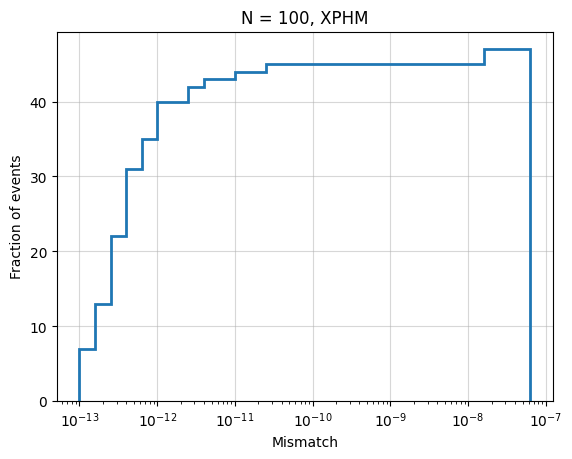

In [10]:
fig, ax = plt.subplots(1, 1)
ax.hist(np.real(np.array(collect_overlap)), 
        cumulative=1,
        histtype='step', lw = 2, bins = 10.0**np.arange(-13, -7, 0.2))
#ax.set_yscale('log')
ax.set_ylabel("Fraction of events")
ax.set_title(f"N = {N}, XPHM")
ax.set_xlabel("Mismatch")
ax.set_xscale('log')

ax.grid(alpha = 0.5)
ax.set_xlabel('Mismatch')
fig.savefig("hist_mm_adjustfring.pdf")
    
